In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np
import pandas as pd

from tensorflow import keras
from keras.layers import Input, Dense
from keras.models import Sequential

In [2]:
df = pd.read_csv('/content/penguins_size.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   culmen_length_mm   342 non-null    float64
 3   culmen_depth_mm    342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                334 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [4]:
df.shape

(344, 7)

In [5]:
df.head()

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [8]:
df.isnull().sum()

,0
species,0
island,0
culmen_length_mm,0
culmen_depth_mm,0
flipper_length_mm,0
body_mass_g,0
sex,0


In [7]:
df = df.dropna()

In [9]:
x = df.drop('species', axis=1)

In [10]:
y = df['species']

In [11]:
x = pd.get_dummies(x, drop_first=True)

In [12]:
from sklearn.model_selection import train_test_split

In [13]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [14]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

In [15]:
le.classes_

array(['Adelie', 'Chinstrap', 'Gentoo'], dtype=object)

In [16]:
from sklearn.preprocessing import StandardScaler

SS = StandardScaler()

x_train = SS.fit_transform(x_train)
x_test = SS.transform(x_test)

In [17]:
model = Sequential([
    Dense(32, activation='relu', input_dim=x_train.shape[1]),
    Dense(16, activation='relu'),
    Dense(3, activation='softmax')
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
input_dim=x_train.shape[1]

In [19]:
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [20]:
history = model.fit(
    x_train,
    y_train,
    epochs=30,
    validation_split=0.1
)

Epoch 1/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 86ms/step - accuracy: 0.2458 - loss: 1.1449 - val_accuracy: 0.3704 - val_loss: 1.0076
Epoch 2/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.3958 - loss: 0.9928 - val_accuracy: 0.6296 - val_loss: 0.8605
Epoch 3/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.6708 - loss: 0.8597 - val_accuracy: 0.7407 - val_loss: 0.7459
Epoch 4/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.8000 - loss: 0.7520 - val_accuracy: 0.8148 - val_loss: 0.6444
Epoch 5/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.8375 - loss: 0.6552 - val_accuracy: 0.8148 - val_loss: 0.5550
Epoch 6/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.8500 - loss: 0.5681 - val_accuracy: 0.8148 - val_loss: 0.4774
Epoch 7/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8750 - loss: 0.4901 - val_accuracy: 0.8519 - val_loss: 0.4077
Epoch 8/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.9167 - loss: 0.4193 - val_accuracy: 0.9630 - val_loss: 0.3460


In [21]:
loss, acc = model.evaluate(x_test, y_test)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.0000 - loss: 0.0238


In [22]:
print("Test Accuracy:", acc)

Test Accuracy: 1.0


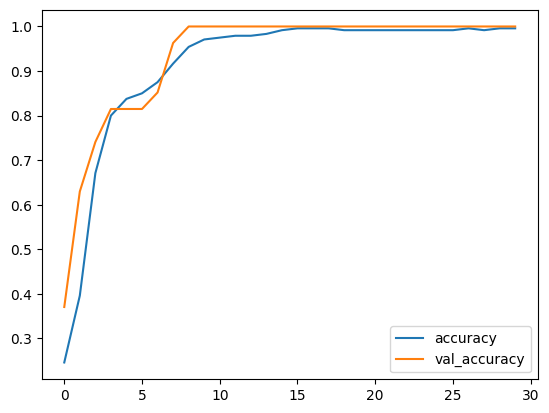

In [23]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.legend()
plt.show()

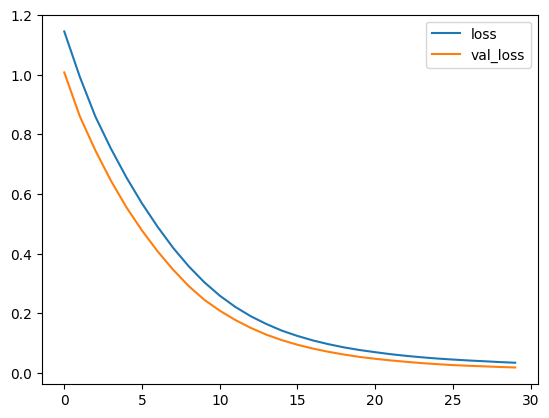

In [24]:
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.show()

Softmax is used because there are three possible penguin species, making this a multi-class classification problem. It gives the probability for each class, whereas a single Sigmoid neuron is mainly used for binary classification.